## Oregon Healthcare Insurance Causal Inference Project

#### Imports

In [1]:
#for data handling 
import pandas as pd
import numpy as np

#for hypothesis testing
from scipy import stats

#for power analysis
from statsmodels.stats.power import TTestIndPower
import statsmodels.formula.api as smf


# for visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
#data loading 
descriptive =  pd.read_stata(r'oregon_puf\OHIE_Public_Use_Files\OHIE_Data\oregonhie_descriptive_vars.dta')
survey12m = pd.read_stata(r'oregon_puf\OHIE_Public_Use_Files\OHIE_Data\oregonhie_survey12m_vars.dta')
stateprogs = pd.read_stata(r'oregon_puf\OHIE_Public_Use_Files\OHIE_Data\oregonhie_stateprograms_vars.dta')
survey0m = pd.read_stata(r'oregon_puf\OHIE_Public_Use_Files\OHIE_Data\oregonhie_survey0m_vars.dta')

print("Descriptive:", descriptive.shape)
print("Survey 12 Months:", survey12m.shape)
print("State Programs:", stateprogs.shape)
print ("Survey 0 months:", survey0m.shape)


Descriptive: (74922, 22)
Survey 12 Months: (74922, 150)
State Programs: (74922, 36)
Survey 0 months: (74922, 123)


Merges the descriptive, baseline survey, 12-month survey, and state programs files into one table on person_id, using left joins to keep everyone regardless of survey response.

In [3]:
#merging the data to create a full profile for the individuals based on person_id 
merged = descriptive.merge(survey0m, on= 'person_id', how = 'left')
merged = merged.merge(survey12m, on = 'person_id', how = 'left')
merged = merged.merge(stateprogs, on = 'person_id', how = 'left')

merged['treatment_num'] = (merged['treatment'] == 'Selected').astype(int)

print('Merged shape:', merged.shape)
print ('Missing treatment values:', merged['treatment'].isnull().sum())
print ('Treatment group count:', merged['treatment'].value_counts())

print('Duplicate ID count:', merged['person_id'].duplicated().sum())

Merged shape: (74922, 329)
Missing treatment values: 0
Treatment group count: treatment
Not selected    45088
Selected        29834
Name: count, dtype: int64
Duplicate ID count: 0


Compares treatment and control groups on pre-lottery characteristics, using t-tests for continuous variables and chi-square tests for categorical ones. 7 of 10 variables tested significant, more than expected by chance.

In [4]:
#creating variables for selected and non selected individual
treatment_group = merged[merged['treatment']== 'Selected']
control_group = merged[merged['treatment'] == 'Not selected']

continuous_var = ['birthyear_0m', 'hhsize_0m', 'hhinc_pctfpl_0m']
categorical_var = ['female_0m', 
                    'race_hisp_0m', 'race_white_0m', 'race_black_0m', 'race_amerindian_0m', 'race_asian_0m', 'race_pacific_0m', 'race_other_qn_0m', 
                    'dia_dx_0m', 'ast_dx_0m', 'hbp_dx_0m', 'dep_dx_0m', 'emp_dx_0m', 'chf_dx_0m'
                    ]

print('Continuous variable t-test results:')

for var in continuous_var:
    t_stats, p_val= stats.ttest_ind(
        treatment_group[var].dropna(),
        control_group[var].dropna()
    )
    print(f'{var}: p-value = {p_val:.4f}')

print('Categorical variable chi-squared result:')

#loop through the variables in a list 
for var in categorical_var:
    contingency = pd.crosstab(merged['treatment'], merged[var])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

    print(f'{var}: p-value: {p_val:.4f}')

Continuous variable t-test results:
birthyear_0m: p-value = 0.0013
hhsize_0m: p-value = 0.3217
hhinc_pctfpl_0m: p-value = 0.0010
Categorical variable chi-squared result:
female_0m: p-value: 0.0019
race_hisp_0m: p-value: 0.0011
race_white_0m: p-value: 0.0043
race_black_0m: p-value: 0.7357
race_amerindian_0m: p-value: 0.0182
race_asian_0m: p-value: 0.0604
race_pacific_0m: p-value: 0.6589
race_other_qn_0m: p-value: 0.3756
dia_dx_0m: p-value: 0.0130
ast_dx_0m: p-value: 0.1043
hbp_dx_0m: p-value: 0.0022
dep_dx_0m: p-value: 0.0000
emp_dx_0m: p-value: 0.1753
chf_dx_0m: p-value: 0.7242


Repeats the comparison as a regression controlling for household list size, which determined selection probability in the lottery. Significant variables drop from 7 of 10 to 5 of 17 in the expanded list.

In [5]:
#a function to convert the categories of columns to 0 and 1 equivalents
def category_if_numeric(col):
    if merged[col].dtype.name == 'category':
        new_col = col +'_num'
        merged[new_col] = merged[col].cat.codes.replace(-1, np.nan)
        return new_col
    return col     

balance_vars = categorical_var + continuous_var

for var in categorical_var:
    print(var, merged[var].cat.categories.to_list())


print('')
print ('Balance check for the household list size')

##OLS regression (linear probability model) controlling for household list size 
for var in balance_vars:
    formula_var = category_if_numeric(var)
    model = smf.ols(f"{formula_var} ~ treatment_num + C(numhh_list)", data = merged, missing = 'drop').fit()
    print(f'{var} p-value on treatment {model.pvalues['treatment_num']:.4f}')

female_0m ['Male', 'Female']
race_hisp_0m ['No', 'Yes']
race_white_0m ['No', 'Yes']
race_black_0m ['No', 'Yes']
race_amerindian_0m ['No', 'Yes']
race_asian_0m ['No', 'Yes']
race_pacific_0m ['No', 'Yes']
race_other_qn_0m ['No', 'Yes']
dia_dx_0m ['NOT Diagnosed', 'Diagnosed']
ast_dx_0m ['NOT Diagnosed', 'Diagnosed']
hbp_dx_0m ['NOT Diagnosed', 'Diagnosed']
dep_dx_0m ['NOT Diagnosed', 'Diagnosed']
emp_dx_0m ['NOT Diagnosed', 'Diagnosed']
chf_dx_0m ['NOT Diagnosed', 'Diagnosed']

Balance check for the household list size
female_0m p-value on treatment 0.0252
race_hisp_0m p-value on treatment 0.1193
race_white_0m p-value on treatment 0.0772
race_black_0m p-value on treatment 0.6032
race_amerindian_0m p-value on treatment 0.0730
race_asian_0m p-value on treatment 0.4662
race_pacific_0m p-value on treatment 0.6691
race_other_qn_0m p-value on treatment 0.9958
dia_dx_0m p-value on treatment 0.0207
ast_dx_0m p-value on treatment 0.3138
hbp_dx_0m p-value on treatment 0.0149
dep_dx_0m p-value on t

Compares the survey-based baseline variables against equivalents recorded for the full population at sign-up, to check whether the remaining imbalance is a randomization problem or a survey non-response pattern. The full-population versions are not significant, so the imbalance is attributed to non-response. Three health conditions have no full-population equivalent and cannot be checked this way.

In [6]:
#to compare survey based responses based on their full population equivalents 
list_check_var =['returned_0m', 'female_list', 'birthyear_list']

for var in list_check_var:
    formula_var = category_if_numeric(var)
    if var == 'returned_0m':
        print (merged.groupby('treatment')[formula_var].mean())
    else:
        model = smf.ols(f"{formula_var} ~ treatment_num + C(numhh_list)", data=merged, missing = 'drop').fit()
        print (f'{var} p-value on treatment: {model.pvalues['treatment_num']:.4f}')


treatment
Not selected    0.456429
Selected        0.448511
Name: returned_0m_num, dtype: float64
female_list p-value on treatment: 0.0692
birthyear_list p-value on treatment: 0.0815


Builds a depression screening score from its two component items, rather than using a lifetime diagnosis flag, which does not reflect change over the study period.

In [7]:
# Creating a column to represent the PHQ score. 
# PHQ-2 is a short clinical depression screening tool and is based of the answers to questions regarding interest in activities and sadness for about 2 weeks
# With a score of 3 or greater meaning the individual is positive for depression
merged['dep_interest_num'] = merged['dep_interest_12m'].cat.codes.replace(-1, np.nan)
merged['dep_sad_num'] = merged['dep_sad_12m'].cat.codes.replace (-1, np.nan)
merged['phq_score'] = merged['dep_interest_num']+ merged['dep_sad_num']
merged['dep_screen_positive'] = np.where(
                                        merged['phq_score'].isna(),
                                        np.nan,
                                        (merged['phq_score']>=3).astype(int)
                                        )

#Tests whether lottery selection affected utilization, health, and financial strain at 12 months,
# using weighted regression to account for the survey's sampling design. 
# 8 of 11 outcomes are significant, in the direction reported by the original study.


outcome_vars = [
    'doc_any_12m', 'er_any_12m', 'hosp_any_12m', 'rx_any_12m',
    'health_gen_bin_12m', 'baddays_phys_12m', 'baddays_ment_12m', 
    'cost_any_owe_12m', 'cost_borrow_12m', 'cost_any_oop_12m', 'dep_screen_positive'
]

#converting the categorical variables to numeric variables
for var in outcome_vars:
    if merged[var].dtype.name == 'category':
        print(var, merged[var].cat.categories.to_list())
        merged[var] = merged [var].cat.codes.replace(-1, np.nan)




print('ITT regression results (numhh_list-controlled, weighted by weight_12m)')

for var in outcome_vars:
    cols_needed = [var, 'treatment_num', 'numhh_list', 'weight_12m']
    data_subset = merged[cols_needed].dropna()

    model = smf.wls(
        f'{var} ~ treatment_num + C(numhh_list)', 
        data= data_subset, 
        weights = data_subset['weight_12m']
        ).fit()
    
    coef = model.params['treatment_num']
    p_val= model.pvalues['treatment_num']
    print (f'{var}: effect = {coef:.4f}, p_value = {p_val:.4f}')


doc_any_12m ['No', 'Yes']
er_any_12m ['No', 'Yes']
hosp_any_12m ['No', 'Yes']
rx_any_12m ['No', 'Yes']
health_gen_bin_12m ['exc/vg/g', 'fair/poor']
cost_any_owe_12m ['No', 'Yes']
cost_borrow_12m ['No', 'Yes']
cost_any_oop_12m ['No', 'Yes']
ITT regression results (numhh_list-controlled, weighted by weight_12m)
doc_any_12m: effect = 0.0611, p_value = 0.0000
er_any_12m: effect = 0.0058, p_value = 0.3119
hosp_any_12m: effect = 0.0027, p_value = 0.4259
rx_any_12m: effect = 0.0221, p_value = 0.0017
health_gen_bin_12m: effect = -0.0395, p_value = 0.0000
baddays_phys_12m: effect = -0.4793, p_value = 0.0013
baddays_ment_12m: effect = -0.5984, p_value = 0.0001
cost_any_owe_12m: effect = -0.0532, p_value = 0.0000
cost_borrow_12m: effect = -0.0449, p_value = 0.0000
cost_any_oop_12m: effect = -0.0591, p_value = 0.0000
dep_screen_positive: effect = -0.0226, p_value = 0.0002


Estimates the minimum effect size the sample could detect, to check whether the two non-significant outcomes reflect a true null result or insufficient power. The minimum detectable effect (Cohen's d = 0.026) is well below the conventional threshold for a small effect.

In [8]:
power_analysis = TTestIndPower()

n_treatment = merged[merged['treatment']== 'Selected'].shape[0]
n_control = merged[merged['treatment']== 'Not selected'].shape[0]
ratio = n_treatment / n_control

minimum_effect = power_analysis.solve_power(
    effect_size= None,
    nobs1= n_treatment,
    ratio= ratio,
    alpha= 0.05,
    power= 0.80
)

print(f'Treatment group size: {n_treatment}')
print(f'Control group size: {n_control}')
print(f'Minimum desired effect (Cohen\'s d): {minimum_effect:.4f}')

Treatment group size: 29834
Control group size: 45088
Minimum desired effect (Cohen's d): 0.0257


In [9]:
chronic_vars = ['dia_dx_0m', 'ast_dx_0m', 'hbp_dx_0m', 'emp_dx_0m', 'chf_dx_0m', 'dep_dx_0m']
chronic_vars_num = [category_if_numeric(var) for var in chronic_vars]
merged['has_chronic_0m'] = (merged[chronic_vars_num].sum(axis = 1) > 0).astype(int)
        

print(merged['has_chronic_0m'].value_counts())

has_chronic_0m
0    58251
1    16671
Name: count, dtype: int64


Tests whether the treatment effect differs for people with a pre-existing chronic condition, using an interaction term. Two outcomes, doctor visits and medical debt borrowing, show a significantly larger effect for that group; both hold after a Bonferroni correction.

In [10]:
for var in outcome_vars:
    subgroup_cols = [var, 'treatment_num', 'has_chronic_0m', 'numhh_list', 'weight_12m']
    subgroup_data = merged[subgroup_cols].dropna()

    model = smf.wls(
        f'{var}~treatment_num * has_chronic_0m + C(numhh_list)',
        data= subgroup_data,
        weights = subgroup_data['weight_12m']
    ).fit()

    interaction_term = 'treatment_num:has_chronic_0m'
    print(f"{var}:")
    print(f"  effect (no chronic condition): {model.params['treatment_num']:.4f}")
    print(f"  extra effect (has chronic condition): {model.params[interaction_term]:.4f}, p-value: {model.pvalues[interaction_term]:.4f}")



doc_any_12m:
  effect (no chronic condition): 0.0494
  extra effect (has chronic condition): 0.0388, p-value: 0.0024
er_any_12m:
  effect (no chronic condition): 0.0099
  extra effect (has chronic condition): -0.0070, p-value: 0.5430
hosp_any_12m:
  effect (no chronic condition): 0.0019
  extra effect (has chronic condition): 0.0034, p-value: 0.6238
rx_any_12m:
  effect (no chronic condition): 0.0284
  extra effect (has chronic condition): -0.0015, p-value: 0.9141
health_gen_bin_12m:
  effect (no chronic condition): -0.0275
  extra effect (has chronic condition): -0.0183, p-value: 0.1578
baddays_phys_12m:
  effect (no chronic condition): -0.2194
  extra effect (has chronic condition): -0.3915, p-value: 0.1879
baddays_ment_12m:
  effect (no chronic condition): -0.3735
  extra effect (has chronic condition): -0.2713, p-value: 0.3768
cost_any_owe_12m:
  effect (no chronic condition): -0.0433
  extra effect (has chronic condition): -0.0180, p-value: 0.1673
cost_borrow_12m:
  effect (no chr

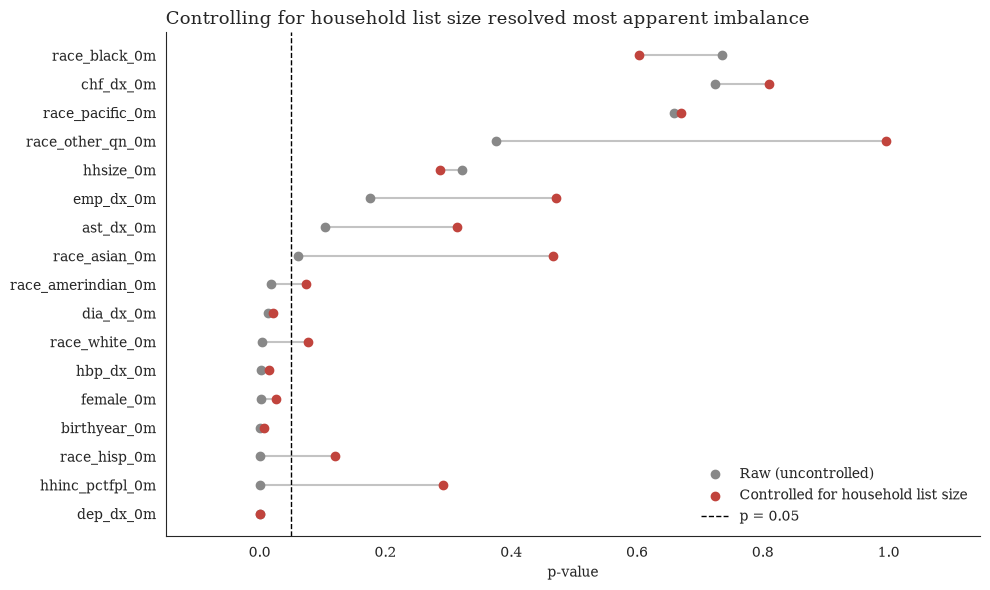

In [11]:
#Visualization 1

sns.set_style('white', {'font.family': 'serif', 'font.serif': ['Georgia', 'DejaVu Serif']})
COLOR_MUTED = '#888888'
COLOR_ACCENT = '#C1443D'

balance_results = []
for var in balance_vars:
    if var in continuous_var:
        t_stat, p_raw = stats.ttest_ind(treatment_group[var].dropna(), control_group[var].dropna())
    else:
        contingency = pd.crosstab(merged['treatment'], merged[var])
        chi2, p_raw, dof, expected = stats.chi2_contingency(contingency)

    formula_var = category_if_numeric(var)
    model = smf.ols(f"{formula_var} ~ treatment_num + C(numhh_list)", data=merged, missing='drop').fit()
    p_controlled = model.pvalues['treatment_num']
    balance_results.append({'variable': var, 'raw_p': p_raw, 'controlled_p': p_controlled})

balance_df = pd.DataFrame(balance_results).sort_values('raw_p')
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(balance_df))
ax.hlines(y=y_pos, xmin=balance_df['controlled_p'], xmax=balance_df['raw_p'], color=COLOR_MUTED, alpha=0.5)
ax.scatter(balance_df['raw_p'], y_pos, color=COLOR_MUTED, label='Raw (uncontrolled)', zorder=3)
ax.scatter(balance_df['controlled_p'], y_pos, color=COLOR_ACCENT, label='Controlled for household list size', zorder=3)
ax.axvline(0.05, color='black', linestyle='--', linewidth=1, label='p = 0.05')
ax.set_yticks(y_pos)
ax.set_yticklabels(balance_df['variable'])
ax.set_xlabel('p-value')
ax.set_title('Controlling for household list size resolved most apparent imbalance', fontsize=13, loc='left')
ax.legend(frameon=False, loc='lower right')
ax.margins(x=0.15, y=0.05)
sns.despine()
plt.tight_layout()
plt.savefig('balance_check_chart.png', dpi=150)
plt.show()

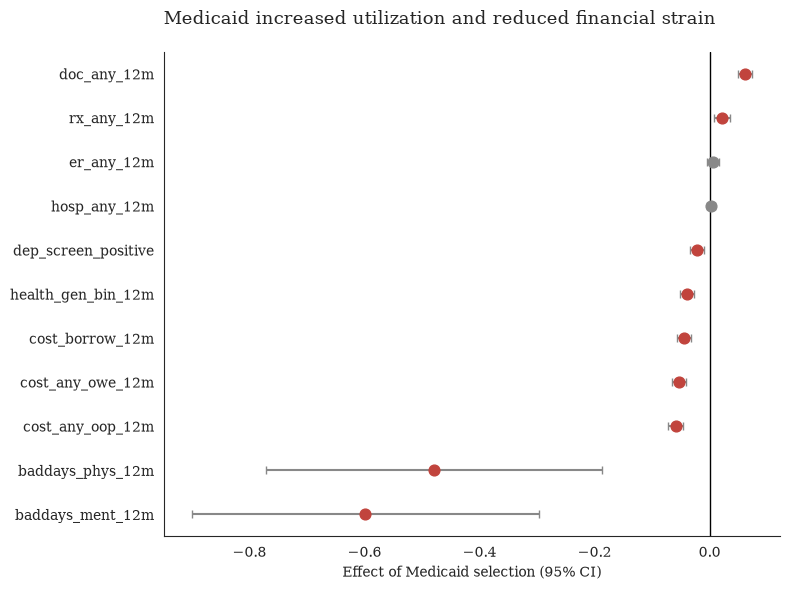

In [12]:
# Visualization 2

outcome_results = []
for var in outcome_vars:
    subset = merged[[var, 'treatment_num', 'numhh_list', 'weight_12m']].dropna()
    model = smf.wls(f'{var} ~ treatment_num + C(numhh_list)', data=subset, weights=subset['weight_12m']).fit()
    coef = model.params['treatment_num']
    ci_low, ci_high = model.conf_int().loc['treatment_num']
    p_val = model.pvalues['treatment_num']
    outcome_results.append({'variable': var, 'effect': coef, 'ci_low': ci_low, 'ci_high': ci_high, 'significant': p_val < 0.05})

outcome_df = pd.DataFrame(outcome_results).sort_values('effect')
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = range(len(outcome_df))
ax.errorbar(outcome_df['effect'], y_pos,
    xerr=[outcome_df['effect'] - outcome_df['ci_low'], outcome_df['ci_high'] - outcome_df['effect']],
    fmt='none', ecolor=COLOR_MUTED, capsize=3, zorder=3)
for i, (eff, sig) in enumerate(zip(outcome_df['effect'], outcome_df['significant'])):
    ax.scatter(eff, i, color=COLOR_ACCENT if sig else COLOR_MUTED, zorder=4, s=60)
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(outcome_df['variable'])
ax.set_xlabel('Effect of Medicaid selection (95% CI)')
ax.set_title('Medicaid increased utilization and reduced financial strain', fontsize=13, loc='left', pad=20)
sns.despine()
plt.tight_layout()
plt.savefig('main_outcomes_chart.png', dpi=150)
plt.show()

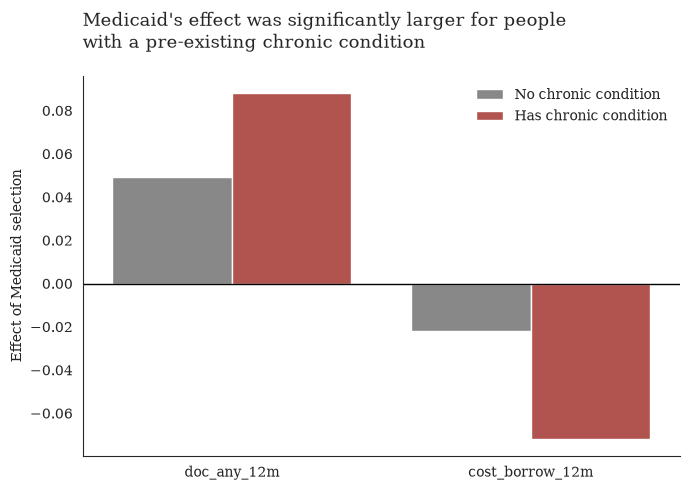

In [13]:
#Visualization 3

subgroup_highlight = ['doc_any_12m', 'cost_borrow_12m']
subgroup_plot_data = []
for var in subgroup_highlight:
    subset = merged[[var, 'treatment_num', 'has_chronic_0m', 'numhh_list', 'weight_12m']].dropna()
    model = smf.wls(f'{var} ~ treatment_num * has_chronic_0m + C(numhh_list)', data=subset, weights=subset['weight_12m']).fit()
    base_effect = model.params['treatment_num']
    chronic_effect = base_effect + model.params['treatment_num:has_chronic_0m']
    subgroup_plot_data.append({'variable': var, 'group': 'No chronic condition', 'effect': base_effect})
    subgroup_plot_data.append({'variable': var, 'group': 'Has chronic condition', 'effect': chronic_effect})

subgroup_df = pd.DataFrame(subgroup_plot_data)
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=subgroup_df, x='variable', y='effect', hue='group', palette=[COLOR_MUTED, COLOR_ACCENT], ax=ax)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Effect of Medicaid selection')
ax.set_xlabel('')
ax.set_title('Medicaid\'s effect was significantly larger for people\nwith a pre-existing chronic condition', fontsize=13, loc='left', pad=20)
ax.legend(frameon=False, title='')
sns.despine()
plt.tight_layout()
plt.savefig('subgroup_extension_chart.png', dpi=150)
plt.show()